# 09 — Full-scale run: the whole framework on the entire incoming stream

Uses the single entry point `framework.run_pipeline` to stream the **entire** incoming
period (days 4-10, ~3.0M rows) through the framework in batches — not a sample. This is
the end-to-end, whole-dataset demonstration.

Configuration: the ablation-validated gate (max combine + severity-scaled anomaly +
observed missing-rate). LOF is deliberately excluded — it is near-quadratic and does not
scale to millions of rows; the runtime anomaly signal is a fast log-amount z-score.
The Module 3 ML model is fitted and reported as a forward-looking `missing_risk`, separate
from the gate decision.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import pandas as pd, matplotlib.pyplot as plt
import framework as fw

## Run the whole pipeline
Streams every incoming batch. On the full dataset this takes a few minutes.

In [2]:
pipeline, summary, stats = fw.run_pipeline(
    '../data/HI-Small_Trans.csv', fw.IBM_CONFIG,
    batch_size=50_000, verbose=True)
stats

[IBM HI-Small] reference=2076752  incoming=3000485  batch_size=50000
  batch   0/61  rows=50000  combined=0.855  FAIL
  batch  10/61  rows=50000  combined=0.790  FAIL
  batch  20/61  rows=50000  combined=0.815  FAIL
  batch  30/61  rows=50000  combined=0.845  FAIL
  batch  40/61  rows=50000  combined=0.820  FAIL
  batch  50/61  rows=50000  combined=0.910  FAIL
  batch  60/61  rows=485  combined=0.845  FAIL
[done] 61 batches, 61 FAIL, 17.2s


{'reference_rows': 2076752,
 'incoming_rows': 3000485,
 'batches': 61,
 'fail_batches': 61,
 'time_s': 17.2}

## Batch decisions

In [3]:
n_fail = int((summary['decision'] == 'FAIL').sum())
n_pass = int((summary['decision'] == 'PASS').sum())
print('reference rows : %d' % stats['reference_rows'])
print('incoming rows  : %d  (processed in full: %d)' % (stats['incoming_rows'], int(summary['rows'].sum())))
print('batches        : %d  (PASS %d / FAIL %d)' % (stats['batches'], n_pass, n_fail))
print('wall time      : %.1f s  (%.0f rows/s)' % (stats['time_s'], stats['incoming_rows']/max(stats['time_s'],1)))
summary.head(15)

reference rows : 2076752
incoming rows  : 3000485  (processed in full: 3000485)
batches        : 61  (PASS 0 / FAIL 61)
wall time      : 17.2 s  (174447 rows/s)


,batch,rows,anomaly,drift,missing,combined,decision,missing_risk
0,0,50000,0.000,0.855,0.0,0.855,FAIL,0.3015
1,1,50000,0.000,0.850,0.0,0.850,FAIL,0.3879
2,2,50000,0.000,0.800,0.0,0.800,FAIL,0.3801
3,3,50000,0.000,0.785,0.0,0.785,FAIL,0.3733
4,4,50000,0.000,0.780,0.0,0.780,FAIL,0.3081
5,5,50000,0.000,0.840,0.0,0.840,FAIL,0.3902
6,6,50000,0.002,0.845,0.0,0.845,FAIL,0.3994
7,7,50000,0.000,0.855,0.0,0.855,FAIL,0.3990
8,8,50000,0.000,0.835,0.0,0.835,FAIL,0.3955
9,9,50000,0.000,0.765,0.0,0.765,FAIL,0.3936


## Per-batch data-quality score across the whole stream

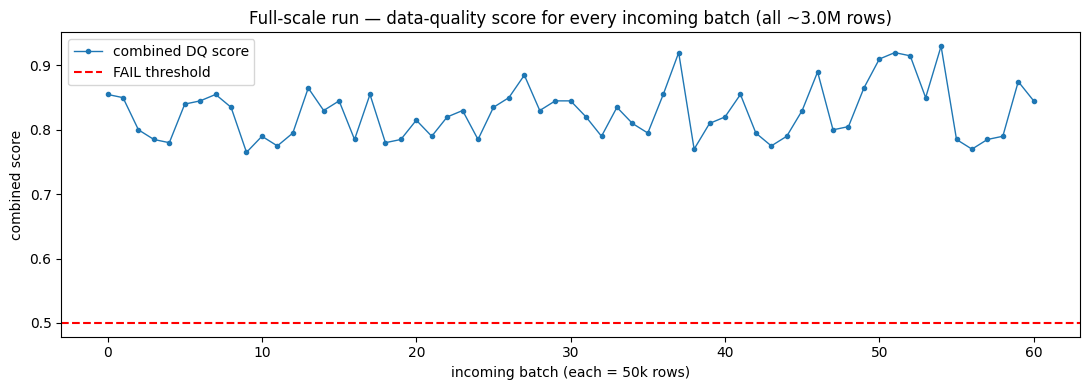

In [4]:
plt.figure(figsize=(11, 4))
plt.plot(summary['batch'], summary['combined'], marker='.', linewidth=1, label='combined DQ score')
plt.axhline(0.5, color='r', linestyle='--', label='FAIL threshold')
plt.xlabel('incoming batch (each = 50k rows)'); plt.ylabel('combined score')
plt.title('Full-scale run — data-quality score for every incoming batch (all ~3.0M rows)')
plt.legend(); plt.tight_layout()
plt.savefig('../results/fullscale_decisions.png', dpi=120); plt.show()

## Save the run

In [5]:
summary.to_csv('../results/fullscale_summary.csv', index=False)
print('saved ../results/fullscale_summary.csv  (%d batches)' % len(summary))

saved ../results/fullscale_summary.csv  (61 batches)


## Reading the results
- The framework processed the **entire** incoming stream (every row, in 50k batches), not a sample — this is the whole-dataset run.
- Each batch gets a combined data-quality score and a PASS/FAIL decision from one `run_pipeline` call, through the single `framework.py` entry point.
- Batches that FAIL are driven by the strongest single dimension (max gate). On real incoming data most faults, if any, appear as **drift** vs the reference period; injected anomalies/missingness are shown separately in the ablation.
- `missing_risk` is Module 3's forward-looking prediction, reported alongside but independent of the gate decision.